First few basic classes will be introduced

In [ ]:
import uuid     # Generally used for generating ids

In [ ]:
class Position2D():
    '''Class used to keep track of 2D positions in cartesian coordinates'''
    def __init__(self, x: float, y: float):
        self.x = x      # X coordinate of the position
        self.y = y      # Y coordinate of the position

    def __add__(self, other: 'Position2D') -> 'Position2D':
        '''Add two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only add Position2D to Position2D")
        return Position2D(self.x + other.x, self.y + other.y)
    
    def __sub__(self, other: 'Position2D') -> 'Position2D':
        '''Subtract two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only subtract Position2D from Position2D")
        return Position2D(self.x - other.x, self.y - other.y)


def distance_to(A: Position2D, B: Position2D) -> float:
    '''Calculate the Euclidean distance to another Position2D'''
    return ((A.x - B.x) ** 2 + (A.y - B.y) ** 2) ** 0.5

In [ ]:
from abc import ABC, abstractmethod
from enum import Enum, auto

class Agent(ABC):
    '''Abstract base class for agents in a 2D environment'''
    def __init__(self, position: Position2D, com_radius: int, velocity: Position2D):
        # User parameters
        self._id = uuid.uuid4()       # Unique identifier for the agent
        self.position = position      # Current position of the agent
        self.com_radius = com_radius  # Communication radius of the agent
        self.velocity = velocity      # Velocity of the agent

        # Inner parameters
        self._state = AgentState.MOVING     # Needed for inner state machine
        self._sensorTask = 0.0              # A readout of task signal
        self._sensorAgent = dict()          # A dictionary of agents that are in the communication radius

    @abstractmethod
    def move(self, new_position: Position2D):
        '''Move the agent to a new position'''
        pass
    
    @abstractmethod
    def readTaskSensor(self, value: float) -> None:
        '''Function to pass information from the environment'''
        pass

    @abstractmethod
    def readCommunication(self, agents: dict) -> None:
        '''Function to pass information from other agents in the environment'''
        pass

    @abstractmethod
    def decide(self) -> None:
        '''Should be called in every iteration -- bascially an implementation of agent behaviour'''
        pass

class AgentState(Enum):
    '''Enumeration for agent states'''
    MOVING = auto()       # Agent is moving
    CALL_OUT = auto()     # Agent detected a task and should inform other agents
    WAITING = auto()      # Agent is waiting for a task to be completed
    RESPONDING = auto()   # Agent received a call-out and tries to find the calling agent

In [ ]:
class Task():
    '''Class to represent a task in the environment'''
    def __init__(self, position: Position2D, capacity: int):
        self._id = uuid.uuid4()      # Unique identifier for the task
        self.position = position    # Position of the task in the environment
        self.agents = dict()        # Dict of agents currently in the task_radius = [agent._id] = agent_obj
        self.completed = False      # Boolean indicating if the task has been completed
        self.capacity = capacity    # Amount of agents needed to complete the task

    def add_agent(self, agent: Agent) -> None:
        '''Update the task status based on the number of agents in its radius'''
        self.agents[agent._id] = agent
        if len(self.agents) >= self.capacity:
            self.completed = True

    def remove_agent(self, agent: Agent) -> None:
        '''Remove an agent from the task's agent list'''
        self.agents.pop(agent._id, None)


    def respawn(self, position: Position2D) -> None:
        '''Respawn the task at a new position'''
        self._id = uuid.uuid4()      # Regenerate UUID
        self.position = position
        self.agents = dict()
        self.completed = False

In [ ]:
import random

class Environment():
    '''Class for managing agent environment'''
    def __init__(self, size: tuple[int, int], task_count: int, task_capacity: int, task_radius: int, agent_radius: int, agent_count: int, agent_class):
        
        # Environment parameters
        # =============================================================================================
        self.width = size[0]                        # Width of the rectangular 2D environment
        self.height = size[1]                       # Height of the rectangular 2D environment

        # Task parameters
        # =============================================================================================
        self.task_count = task_count                # Number of tasks in the environment
        self.task_capacity = task_capacity          # Amount of agents needed in task_radius to complete a task
        self.task_radius = task_radius              # Radius of each task's area of effect
        
        # Agent parameters
        # =============================================================================================
        self.agent_radius = agent_radius            # Radius of the agent communication area
        self.agent_count = agent_count              # Number of agents in the environment
        self.agent = agent_class                    # Class of agents in the environment - must be a subclass of Agent

        # Environment state
        # =============================================================================================
        self.tasks = list()                        # List of tasks in the environment
        self.agents = list()                       # List of agents in the environment
        self.tasks_done = 0                        # Number of tasks completed in the environment
        self.iteration = 0                         # Current iteration of the environment

    def initialize(self) -> None:
        '''Initialize the environment with tasks and agents'''

        # Reset agent and task lists
        self.tasks = list()
        self.agents = list()

        # Create tasks
        for _ in range(self.task_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            task = Task(Position2D(x, y), self.task_capacity)
            self.tasks.append(task)
        
        # Create agents
        for _ in range(self.task_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            agent = self.agent(Position2D(x, y))
            self.agents.append(agent)

        # Zero the counters        
        self.tasks_done = 0
        self.iteration = 0

    def __repr__(self) -> str:
        return f"Environment(width={self.width}, height={self.height}, task_count={self.task_count}, task_capacity={self.task_capacity}, task_radius={self.task_radius}, agent_radius={self.agent_radius})"


### Implementation of simple agent

In [ ]:
class SimpleAgent(Agent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, com_radius: int, velocity: Position2D):
        super().__init__(position, com_radius, velocity)
        
    def move(self, new_position: Position2D):
        '''Move the agent to a new position'''
        self.position = new_position

### Test zone

In [ ]:
# Params for running the environment
env_size = (1000, 1000)                # Size of the environment (width, height)
task_count = 100                      # Number of tasks in the environment
task_capacity = 3                   # Number of agents required to complete a task
task_radius = 100                   # Radius within which agents can work on a task
agent_radius = 50                   # Radius within which agents can communicate
agent_count = 10                    # Number of agents in the environment

def agentInit(a):
    #print("temp")
    return [None]

In [42]:
env = Environment(env_size, task_count, task_capacity, task_radius, agent_radius, agent_count, agent_class=agentInit)

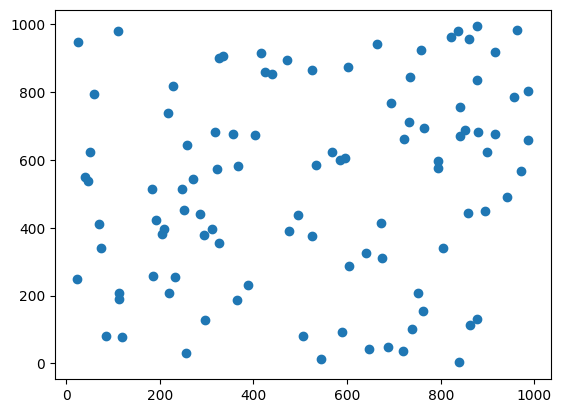

In [62]:
import matplotlib.pyplot as plt

env.initialize()

x_arr = []
y_arr = []
for task in env.tasks:
    x_arr.append(task.position.x)
    y_arr.append(task.position.y)

plt.scatter(x_arr, y_arr)